# Tema 1 – Introducere în Machine Learning (OUALD, seria CB)

**Autor:**
- Văleanu Andrei — andrei.valeanu03@stud.acs.upb.ro

Notebook-ul urmează firul din laborator: întâi analiza exploratorie, apoi preprocesarea datelor, apoi modelele și evaluarea. Ordinea din cerință: **3.1 EDA** → **3.2** preprocesare → **3.3** clasificare / regresie / raportare experimente.

## Dependențe (din notebook)

Instalarea bibliotecilor se face **direct din celula următoare** — nu trebuie deschis terminalul și nu depinde de Windows / Linux: Jupyter trimite comanda către interpretorul Python **folosit acum** de acest notebook.

- Deschide `Tema1_IA_OUALD.ipynb` din folderul unde se află și `requirements.txt`.
- Rulezi celula de mai jos (la prima rulare poate dura câteva minute). Dacă apare solicitare de **restart kernel**, după restart execuți din nou celulele de sus în jos.

Prima celulă de cod instalează automat din `requirements.txt` (inclusiv **catboost** și **xgboost**); rulează-o după ce ai deschis folderul **Tema1-CB** ca director de lucru.


In [21]:
#     Dependențe (un singur loc): Moodle + Kaggle + sklearn + CatBoost + XGBoost
# Deschide notebook-ul din folderul unde există `requirements.txt` (Tema1-CB).
from pathlib import Path

_ROOT = Path.cwd()
if not (_ROOT / "requirements.txt").is_file():
    raise FileNotFoundError(
        "Lipsește requirements.txt. Deschide Jupyter din folderul Tema1-CB "
        "(File → Open Folder…) sau cd în acel folder înainte de a porni kernelul."
    )

%pip install -q --upgrade pip
%pip install -q -r requirements.txt


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


---
## 3.1 Explorarea datelor (Exploratory Data Analysis) [2p]

**Problemă:** set OUALD — clasificare multiclasă (`final_result`), regresie (`final_coursework_score`).

**Fișiere:** `CB_OUALD_train.csv`, `CB_OUALD_test.csv` în același folder cu notebook-ul. Dacă apare și `CB_OUALD_val.csv` pe platformă, în cod poți încărca validarea din acel fișier în locul împărțirii automate train/validation.

Enunțul sugerează să nu depășești **circa 15 figuri** pentru întreg EDA-ul; contează mai mult claritatea și legătura cu pașii următori (preprocesare, modele), nu numărul de grafice.

### Ghid rapid — sectiunea 3.1 (EDA)

- **Buget figuri PDF:** enuntul limiteaza la ~15 figuri zona EDA; alege cele mai relevante (clase, corelatii, cateva numerice reprezentative).
- **Train vs validare:** graficele pe clase folosesc `df_train_eda` si `df_val` (validare din fisier sau din split). Comparatia train/val arata daca distributia claselor e similara.
- **Heatmap:** corelatii Pearson intre numerice; nu inseamna cauzalitate, doar asociere liniara.
- **Cramers V / corelatii cu tinta:** masoara legatura categorii–tinta sau numeric–tinta; foloseste la interpretare, nu la demonstratie de cauzalitate.


In [22]:
# Celule comune: căi, reproducibilitate, încărcare date
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_theme(style="whitegrid", context="notebook")

BASE = Path(".")
TRAIN_PATH = BASE / "CB_OUALD_train.csv"
VAL_PATH = BASE / "CB_OUALD_val.csv"  # opțional, dacă îl primesc pe Moodle

df_train = pd.read_csv(TRAIN_PATH)
print("Dimensiune train:", df_train.shape)
display(df_train.head())

Dimensiune train: (18802, 43)


,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,...,clicks_quiz,clicks_repeatactivity,clicks_resource,clicks_sharedsubpage,clicks_subpage,clicks_url,submission_rate_early,refs_oucontent,macro_stats,clicks_freq_init
0,AAA,2013J,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,...,0.0,0.0,9.0,0.0,23.0,1.0,0.333333,337.009376,-0.055726,mid
1,AAA,2013J,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,...,0.0,0.0,5.0,0.0,63.0,NaN,0.333333,233.617995,0.073017,low
2,AAA,2013J,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,...,0.0,0.0,10.0,0.0,81.0,40.0,0.333333,373.091984,0.544510,high
3,AAA,2013J,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,...,0.0,0.0,7.0,0.0,33.0,6.0,0.333333,349.299753,-0.800788,low
4,AAA,2013J,M,Wales,A Level or Equivalent,80-90%,35-55,0,60,N,...,0.0,0.0,6.0,0.0,41.0,17.0,0.333333,273.649621,0.058026,mid


### 3.1.1 Tipuri de atribute și plaje de valori

Separăm atribute **numerice continue** (statistici + boxplot) de cele **categoriale / ordinale** (număr valori unice + histogramă pe frevențe). Cerință minimă: analiză pentru **minim 3 atribute** distincte (aici le acoperim pe mai multe, grupate logic).

In [23]:
TARGET_CLF = "final_result"
TARGET_REG = "final_coursework_score"

num_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
# eliminăm identificatori pur numerici din vizualizări dacă e cazul (păstrăm în tabele descriptive)
cat_cols = df_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Coloane numerice:", len(num_cols))
print("Coloane non-numerice:", len(cat_cols))

# Tabel cerut pentru numerice: count non-null, medie, std, min, 25%, 50%, 75%, max
desc = df_train[num_cols].describe(percentiles=[0.25, 0.5, 0.75]).T
desc.insert(0, "count_non_na", df_train[num_cols].notna().sum())
desc = desc.rename(columns={"50%": "median"})
display(desc.round(4))

Coloane numerice: 33
Coloane non-numerice: 10


,count_non_na,count,mean,std,min,25%,median,75%,max
num_of_prev_attempts,18802,18802.0,0.1673,0.4798,0.0000,0.0000,0.0000,0.0000,6.0000
studied_credits,18802,18802.0,80.4385,37.0592,30.0000,60.0000,60.0000,120.0000,430.0000
date_registration,18799,18799.0,-67.8662,47.8515,-311.0000,-98.0000,-54.0000,-29.0000,167.0000
date_unregistration,3542,3542.0,111.3859,62.1861,-196.0000,59.0000,108.0000,159.0000,444.0000
module_presentation_length,18802,18802.0,256.0287,13.3263,234.0000,241.0000,262.0000,268.0000,269.0000
n_assessments_early,18787,18787.0,2.6558,1.1500,1.0000,2.0000,2.0000,3.0000,6.0000
mean_score_early,18770,18770.0,74.3645,17.1557,0.0000,66.5000,78.3333,86.6667,100.0000
weighted_mean_score_early,18780,18780.0,73.4269,16.5703,0.0000,64.6977,76.0000,85.6250,100.0000
final_coursework_score,18802,18802.0,70.4633,16.8465,0.0000,61.0000,73.1246,83.0000,100.0000
total_clicks_early,18802,18802.0,791.4626,860.5910,0.0000,262.0000,523.0000,1004.7500,12783.0000


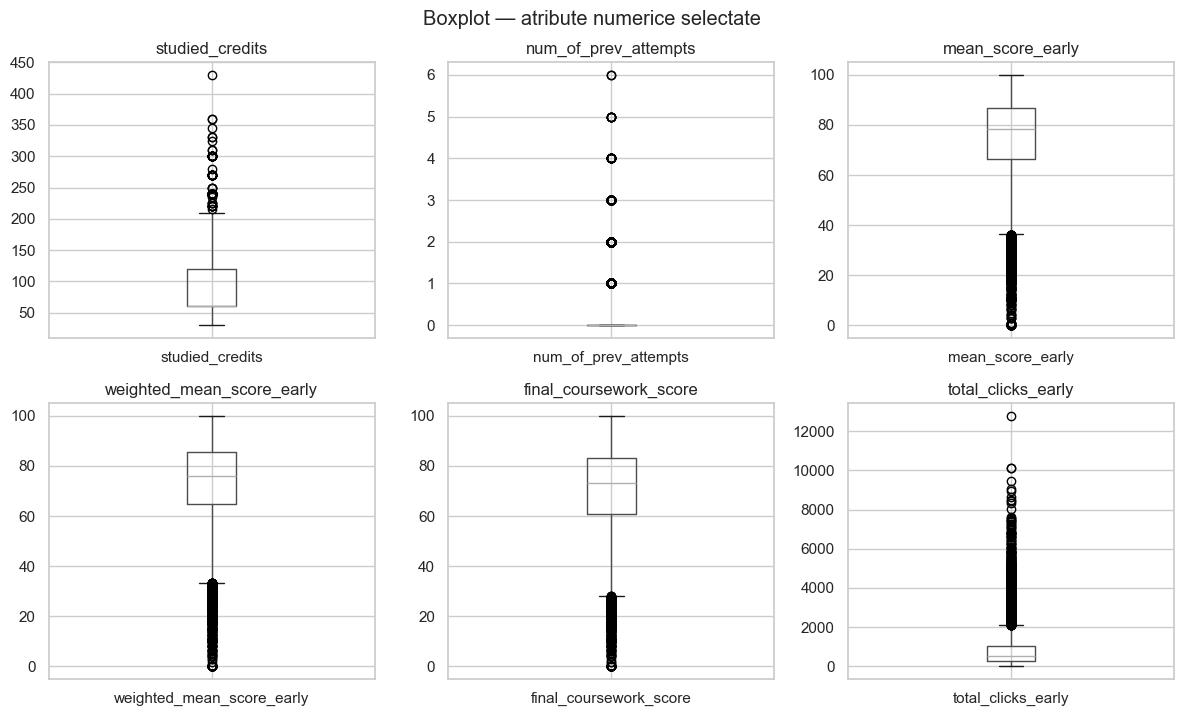

In [24]:
# Boxplot-uri pentru un subset reprezentativ de numerice continue (evităm zeci de figuri)
box_numeric = [
    "studied_credits", # reprezintă numărul de credite studiate, care poate fi un indicator al implicării studentului
    "num_of_prev_attempts", # indică numărul de încercări anterioare, ceea ce poate reflecta dificultatea cursului sau perseverența studentului
    "mean_score_early", # reprezintă media scorurilor obținute în primele etape, oferind o idee despre performanța inițială a studentului
    "weighted_mean_score_early", # reprezintă media ponderată a scorurilor obținute în primele etape, oferind o perspectivă mai nuanțată asupra performanței inițiale a studentului
    "final_coursework_score", # reprezintă scorul final al lucrării de curs, care este un indicator direct al performanței studentului în curs
    "total_clicks_early", # reprezintă numărul total de clicuri în primele etape, oferind o idee despre nivelul de interacțiune al studentului cu platforma
]
box_numeric = [c for c in box_numeric if c in df_train.columns]

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.ravel()
for ax, col in zip(axes, box_numeric):
    df_train[[col]].boxplot(ax=ax, vert=True)
    ax.set_title(col)
plt.tight_layout()
plt.suptitle("Boxplot — atribute numerice selectate", y=1.02)
plt.show()

,count_non_na,n_unique
code_module,18802,6
code_presentation,18802,4
gender,18802,2
region,18802,13
highest_education,18802,5
imd_band,18028,10
age_band,18802,3
disability,18802,2
final_result,18802,4
clicks_freq_init,18742,3


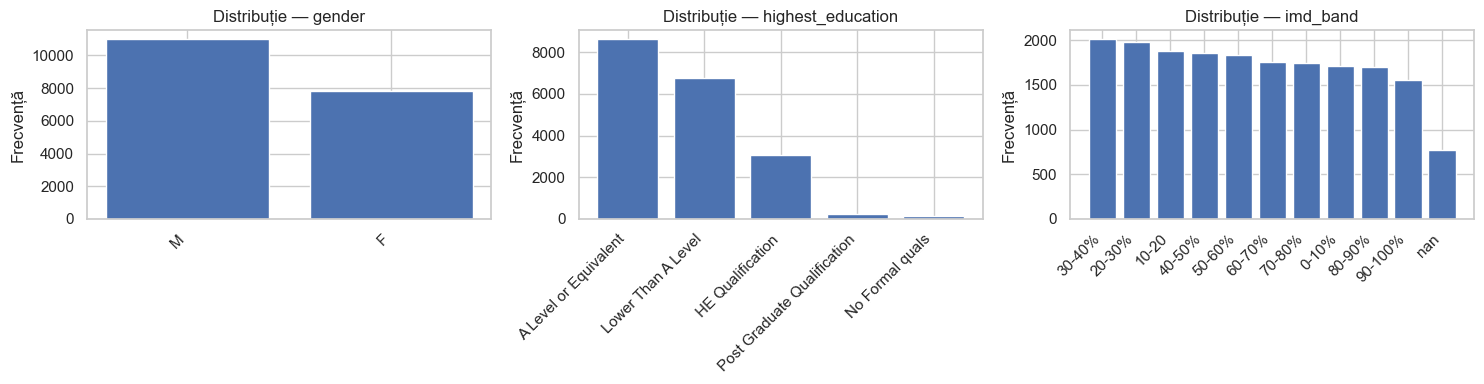

In [25]:
# Categorice / ordinale: count non-null și număr valori unice + histograme (frevențe)
cat_summary = pd.DataFrame({
    "count_non_na": df_train[cat_cols].notna().sum(),
    "n_unique": df_train[cat_cols].nunique(dropna=True),
})
display(cat_summary)

hist_cats = ["gender", "highest_education", "imd_band"]
hist_cats = [c for c in hist_cats if c in df_train.columns]

fig, axes = plt.subplots(1, len(hist_cats), figsize=(5 * len(hist_cats), 4))
if len(hist_cats) == 1:
    axes = [axes]
for ax, col in zip(axes, hist_cats):
    vc = df_train[col].value_counts(dropna=False)
    ax.bar(range(len(vc)), vc.values)
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels(vc.index.astype(str), rotation=45, ha="right")
    ax.set_title(f"Distribuție — {col}")
    ax.set_ylabel("Frecvență")
plt.tight_layout()
plt.show()

### 3.1.2 Echilibrul claselor (`final_result`)

Bar plot / count plot pe **train** și pe **validare**. Dacă nu există fișier `_val`, construim validarea prin `train_test_split` **stratificat** pe `final_result` (aceeași logică ca la experimente ulterioare).

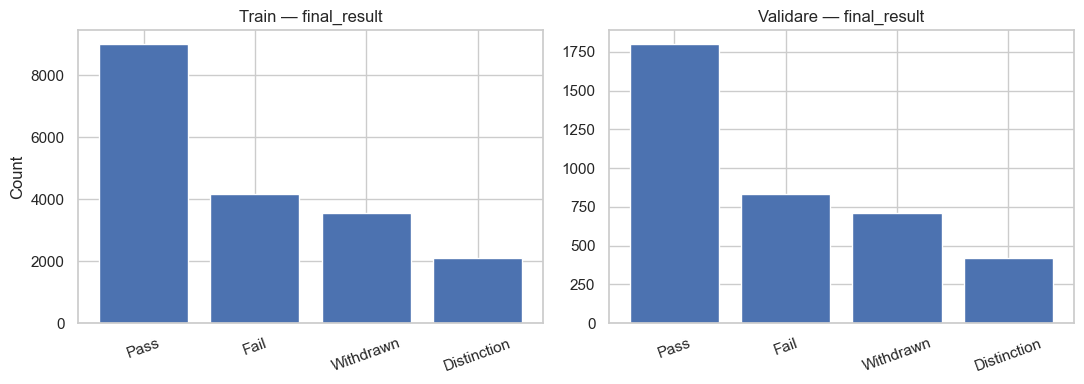

Proporții train:


final_result
Pass           0.4781
Fail           0.2210
Withdrawn      0.1890
Distinction    0.1118
Name: proportion, dtype: float64

Proporții validare:


final_result
Pass           0.4781
Fail           0.2210
Withdrawn      0.1890
Distinction    0.1119
Name: proportion, dtype: float64

In [26]:
if VAL_PATH.exists():
    df_val = pd.read_csv(VAL_PATH)
else:
    _, df_val = train_test_split(
        df_train,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=df_train[TARGET_CLF],
    )

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
order = df_train[TARGET_CLF].value_counts().index
vc_tr = df_train[TARGET_CLF].value_counts().reindex(order)
axes[0].bar(range(len(vc_tr)), vc_tr.values)
axes[0].set_xticks(range(len(vc_tr)))
axes[0].set_xticklabels(vc_tr.index.astype(str), rotation=20)
axes[0].set_title("Train — final_result")
axes[0].set_ylabel("Count")
vc_va = df_val[TARGET_CLF].value_counts().reindex(order)
axes[1].bar(range(len(vc_va)), vc_va.values)
axes[1].set_xticks(range(len(vc_va)))
axes[1].set_xticklabels(vc_va.index.astype(str), rotation=20)
axes[1].set_title("Validare — final_result")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

print("Proporții train:")
display(df_train[TARGET_CLF].value_counts(normalize=True).round(4))
print("Proporții validare:")
display(df_val[TARGET_CLF].value_counts(normalize=True).round(4))

### 3.1.3 Corelații

- **Numerice**: matrice Pearson + heatmap (identificare redundanțe).
- **Categorice**: test **Chi-pătrat** pe tabele de contingență (perechi de categorii); pentru interpretare rapidă afișăm Cramér's V pentru perechi selectate.
- **Cerință minimă din enunț**: legături între predictori și **ținte** — numeric vs clasificare, categoric vs clasificare, numeric vs regresie, categoric vs regresie.

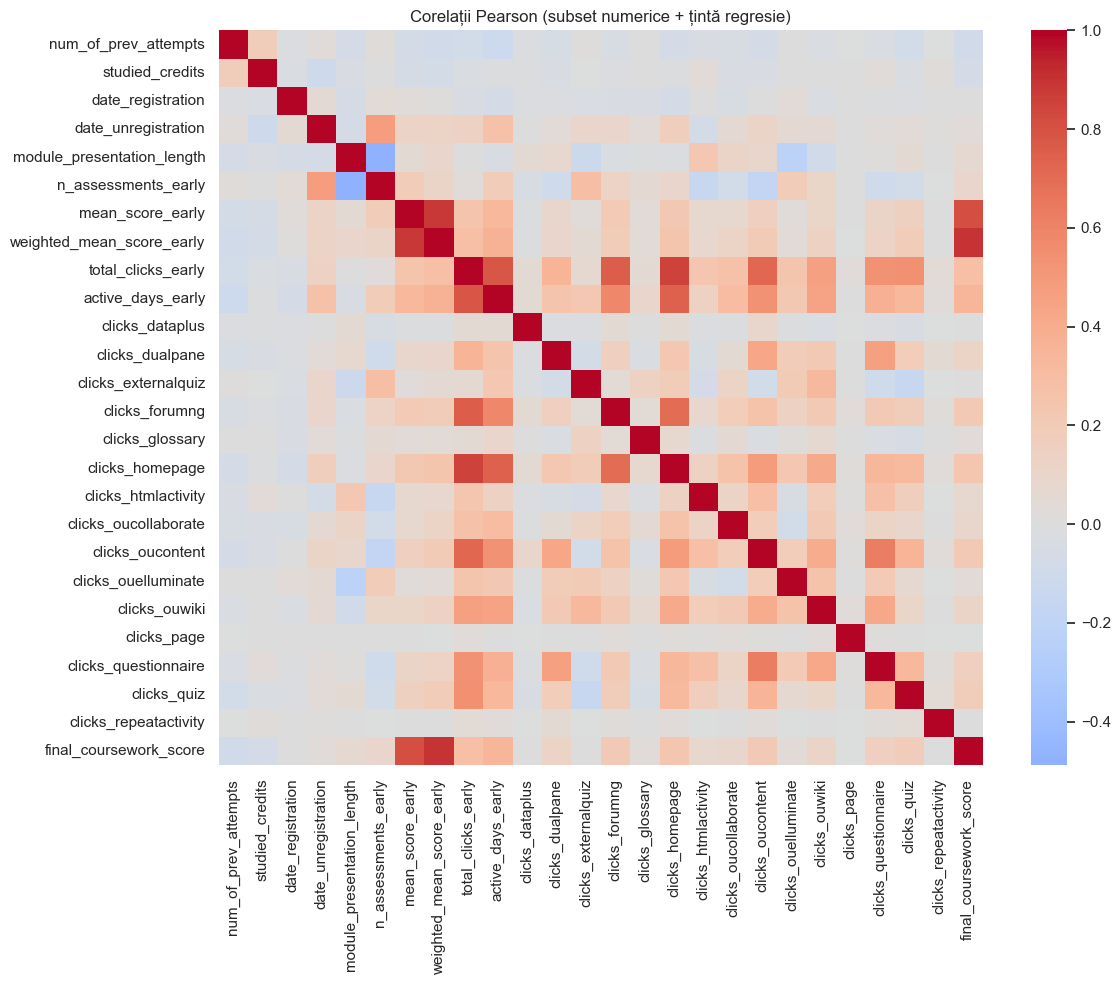

In [27]:
# Heatmap corelații Pearson între numerice (subset pentru lizibilitate)
corr_cols = [c for c in num_cols if c not in {TARGET_REG}][:25]
if TARGET_REG in num_cols and TARGET_REG not in corr_cols:
    corr_cols.append(TARGET_REG)
cm = df_train[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap="coolwarm", center=0)
plt.title("Corelații Pearson (subset numerice + țintă regresie)")
plt.tight_layout()
plt.show()

In [28]:
from scipy.stats import chi2_contingency


def cramers_v(confusion: pd.DataFrame) -> float:
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    r, k = confusion.shape
    denom = n * (min(k - 1, r - 1))
    if denom <= 0:
        return float("nan")
    return np.sqrt(chi2 / denom)


chi_pairs = [("gender", "highest_education"), ("gender", "region")]
rows = []
for a, b in chi_pairs:
    if a in df_train.columns and b in df_train.columns:
        ct = pd.crosstab(df_train[a], df_train[b])
        chi2, p, _, _ = chi2_contingency(ct)
        rows.append({"var1": a, "var2": b, "chi2": chi2, "p_value": p, "cramers_v": cramers_v(ct)})
display(pd.DataFrame(rows))

,var1,var2,chi2,p_value,cramers_v
0,gender,highest_education,40.294453,3.762045e-08,0.046294
1,gender,region,108.716960,1.073049e-17,0.076041


In [29]:
from sklearn.preprocessing import LabelEncoder

# Numeric vs clasificare: corelație Pearson cu eticheta encodată (ordonare arbitrară — doar exploratoriu)
le = LabelEncoder()
y_enc = le.fit_transform(df_train[TARGET_CLF].astype(str))
numeric_for_corr = [c for c in num_cols if c != TARGET_REG][:15]
corr_clf = pd.Series(
    [np.corrcoef(df_train[c].fillna(df_train[c].median()), y_enc)[0, 1] for c in numeric_for_corr],
    index=numeric_for_corr,
    name="corr(num, encoded_final_result)",
).abs().sort_values(ascending=False)
display(corr_clf.to_frame())

# Categoric vs clasificare: Chi² cu final_result
chi_vs_target = []
for col in [c for c in cat_cols if c != TARGET_CLF][:10]:
    ct = pd.crosstab(df_train[col], df_train[TARGET_CLF])
    chi2, p, _, _ = chi2_contingency(ct)
    chi_vs_target.append({"feature": col, "chi2": chi2, "p_value": p, "cramers_v": cramers_v(ct)})
display(pd.DataFrame(chi_vs_target).sort_values("cramers_v", ascending=False))

,"corr(num, encoded_final_result)"
weighted_mean_score_early,0.233252
mean_score_early,0.216291
active_days_early,0.137251
total_clicks_early,0.128323
n_assessments_early,0.117317
clicks_forumng,0.101880
studied_credits,0.055411
clicks_dualpane,0.049356
date_registration,0.041670
date_unregistration,0.033530


,feature,chi2,p_value,cramers_v
0,code_module,836.290837,1.496355e-168,0.121763
4,highest_education,665.061112,1.319321e-134,0.108585
7,disability,127.697262,1.695448e-27,0.082412
5,imd_band,350.736625,4.860461e-58,0.080530
1,code_presentation,226.390292,9.467651e-44,0.063353
3,region,194.912761,1.037723e-23,0.058784
6,age_band,127.479152,4.361815e-25,0.058224
8,clicks_freq_init,81.946798,1.414633e-15,0.046757
2,gender,19.030178,2.694988e-04,0.031814


In [30]:
# Numeric vs regresie: Pearson cu final_coursework_score
reg_corr = df_train[num_cols].corrwith(df_train[TARGET_REG]).abs().sort_values(ascending=False)
display(reg_corr.to_frame("corr_cu_final_coursework_score").head(15))

# Categoric vs regresie: raport F one-way ANOVA (schelet simplu)
from scipy.stats import f_oneway

anova_rows = []
for col in [c for c in cat_cols if c not in {TARGET_CLF}][:8]:
    groups = [g[TARGET_REG].dropna().values for _, g in df_train.groupby(col)]
    groups = [g for g in groups if len(g) > 1]
    if len(groups) < 2:
        continue
    f_stat, p = f_oneway(*groups)
    anova_rows.append({"feature": col, "F": f_stat, "p_value": p})
display(pd.DataFrame(anova_rows).sort_values("F", ascending=False))

,corr_cu_final_coursework_score
final_coursework_score,1.000000
weighted_mean_score_early,0.898859
mean_score_early,0.815308
active_days_early,0.345432
total_clicks_early,0.287395
clicks_homepage,0.240307
refs_oucontent,0.220405
clicks_oucontent,0.220294
clicks_forumng,0.209310
clicks_quiz,0.177954


,feature,F,p_value
0,code_module,201.667563,4.083129e-210
4,highest_education,126.030403,2.319340e-106
7,disability,79.243007,5.981543e-19
5,imd_band,39.993719,2.606706e-71
6,age_band,36.358376,1.738677e-16
2,gender,25.615287,4.206555e-07
1,code_presentation,20.121190,5.150981e-13
3,region,9.962432,8.912977e-20


### Interpretare scurtă (pentru PDF)

- **Dezechilibru clase:** proporțiile `final_result` nu sunt uniforme (Pass dominant); la clasificare ai grijă la acuratețe vs F1 / precision–recall pe clase rare.
- **Redundanță:** din corelații poți marca perechi foarte apropiate de 1; în 3.2 poți decide dacă elimini un predictor (vezi opțional).
- **Predictori utili:** rezumă din tabelele Chi² / ANOVA care variabile par legate de ținte.


### Reminder: ce reprezinta randurile din OUALD

Un rand ≈ **student inscris la un modul** intr-o **prezentare** (semestru). Coloanele early (click-uri, note la evaluari timpurii, zile active) sint comportament **inainte de rezultatul final**. Tintele sint `final_result` (clasificare) si `final_coursework_score` (regresie).


---
## 3.2 Preprocesarea datelor [2p]

Pași urmați: **(1)** valori lipsă și **imputare**; **(2)** outlieri numerici (IQR) tratați ca lipsă, apoi imputare; **(3)** (*opțional*) eliminare redundantă; **(4)** **standardizare** numerice și **one-hot** pentru categorii (matrice numerică pentru sklearn).

Transformările se **antrenează pe train** și se aplică la fel pe validare.


### 3.2.1 Date lipsă — imputare

Pentru **numerice**: de regulă **mediana** (robustă); pentru **categorice**: **modă**, apoi encodare în pipeline-ul de mai jos.

*Exemplu de justificare în raport:* pentru `imd_band`, imputarea cu modă păstrează categoriile fără a inventa etichete noi.


In [31]:
# Acelasi logic de split ca in 3.1
if not VAL_PATH.exists():
    df_train_eda, df_val = train_test_split(
        df_train,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=df_train[TARGET_CLF],
    )
else:
    df_train_eda = df_train.copy()
    df_val = pd.read_csv(VAL_PATH)

num_feat = [c for c in df_train_eda.select_dtypes(include=[np.number]).columns if c != TARGET_REG]
cat_feat = [c for c in df_train_eda.select_dtypes(exclude=[np.number]).columns if c != TARGET_CLF]

feat_cols = num_feat + cat_feat
missing_summary = (
    pd.DataFrame(
        {
            "n_missing": df_train_eda[feat_cols].isna().sum(),
            "pct": (df_train_eda[feat_cols].isna().sum() / len(df_train_eda) * 100).round(2),
        }
    )
    .query("n_missing > 0")
    .sort_values("n_missing", ascending=False)
)
display(missing_summary.head(20))

X_train_raw = df_train_eda[feat_cols].copy()
X_val_raw = df_val[feat_cols].copy()
y_train_clf = np.asarray(df_train_eda[TARGET_CLF], dtype=object)
y_val_clf = np.asarray(df_val[TARGET_CLF], dtype=object)
y_train_reg = df_train_eda[TARGET_REG].values
y_val_reg = df_val[TARGET_REG].values


,n_missing,pct
date_unregistration,12205,81.14
clicks_resource,4681,31.12
clicks_url,4450,29.59
imd_band,608,4.04
clicks_homepage,54,0.36
clicks_glossary,54,0.36
clicks_htmlactivity,54,0.36
clicks_forumng,54,0.36
clicks_oucollaborate,54,0.36
clicks_externalquiz,54,0.36


### 3.2.2 Valori extreme (IQR)

Limite **Q1 − 1,5·IQR** și **Q3 + 1,5·IQR** estimate pe **train**; valorile din afara intervalului sunt marcate NaN și înlocuite la imputare.


In [32]:
OUTLIER_COL = "total_clicks_early"


def bounds_iqr(s: pd.Series, k: float = 1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr


def mask_outliers(series: pd.Series, lo, hi):
    return (series < lo) | (series > hi)


X_tr = X_train_raw.copy()
X_va = X_val_raw.copy()

lo, hi = bounds_iqr(X_tr[OUTLIER_COL].dropna())
print(f"{OUTLIER_COL}: IQR bounds [{lo:.2f}, {hi:.2f}]")

m_tr = mask_outliers(X_tr[OUTLIER_COL], lo, hi)
m_va = mask_outliers(X_va[OUTLIER_COL], lo, hi)
print(f"Outlieri -> NaN train: {m_tr.sum()}, validare: {m_va.sum()}")

X_tr.loc[m_tr, OUTLIER_COL] = np.nan
X_va.loc[m_va, OUTLIER_COL] = np.nan


total_clicks_early: IQR bounds [-851.00, 2117.00]
Outlieri -> NaN train: 1017, validare: 275


### 3.2.3 (Opțional) Redundanță

Perechi numerice cu |Pearson| mare pe train (nu eliminăm automat). În raport explici dacă renunți la o coloană.


In [33]:
corr_only_num = X_tr[num_feat].corr(numeric_only=True)
pairs = []
for i, a in enumerate(corr_only_num.columns):
    for b in corr_only_num.columns[i + 1 :]:
        r = corr_only_num.loc[a, b]
        if np.isfinite(r) and abs(r) >= 0.95:
            pairs.append((a, b, r))
pairs = sorted(pairs, key=lambda t: abs(t[2]), reverse=True)
display(pd.DataFrame(pairs, columns=["feat_a", "feat_b", "pearson"]).head(15))


,feat_a,feat_b,pearson
0,n_assessments_early,submission_rate_early,1.000000
1,clicks_oucontent,refs_oucontent,0.999825


### 3.2.4 Standardizare + pipeline complet

`SimpleImputer` + `StandardScaler` pe numerice; pe categorice `SimpleImputer` + `OneHotEncoder(handle_unknown='ignore')` ca să obții o singură matrice numerică pentru modelele din 3.3.


In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_pipe = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
categorical_pipe = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_feat),
        ("cat", categorical_pipe, cat_feat),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

X_train_prep = preprocessor.fit_transform(X_tr)
X_val_prep = preprocessor.transform(X_va)

feature_names = preprocessor.get_feature_names_out()
print("Shape după preprocess:", X_train_prep.shape, X_val_prep.shape)
print("Primele features:", feature_names[:8])

X_train_prep_df = pd.DataFrame(X_train_prep, columns=feature_names)
display(X_train_prep_df.iloc[:, : min(6, X_train_prep_df.shape[1])].describe().round(4))


Shape după preprocess: (15041, 80) (3761, 80)
Primele features: ['num_of_prev_attempts' 'studied_credits' 'date_registration'
 'date_unregistration' 'module_presentation_length' 'n_assessments_early'
 'mean_score_early' 'weighted_mean_score_early']


,num_of_prev_attempts,studied_credits,date_registration,date_unregistration,module_presentation_length,n_assessments_early
count,15041.0000,15041.0000,15041.0000,15041.0000,15041.0000,15041.0000
mean,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000
std,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
min,-0.3459,-1.3559,-5.0469,-11.2285,-1.6422,-1.4409
25%,-0.3459,-0.5483,-0.6426,-0.0262,-1.1183,-0.5767
50%,-0.3459,-0.5483,0.2922,-0.0262,0.4532,-0.5767
75%,-0.3459,1.0670,0.8116,-0.0262,0.9022,0.2875
max,12.2818,9.4125,4.8835,12.3553,0.9770,2.8801


### Rezumat 3.2

- Imputare mediană / modă; outlieri IQR pe `total_clicks_early`; numerice scalate; categorice one-hot.
- Variabile: `X_train_prep`, `X_val_prep`, ținte `y_*` pentru **3.3**.

---
**Următorul pas:** **3.3** — modele și evaluare.


### Rezumat tehnic 3.2 (ce face pipeline-ul)

- **Imputare:** median pentru numerice, mod pentru categorice (train fit, aplicat train/val/test).
- **Outlieri IQR** pe coloana configurata: valori extreme devin NaN, apoi tot imputare.
- **Standardizare** doar pe trasaturile numerice din pipeline; coloanele categorice ramin pentru encodari separate unde e cazul.
- Orice schimbare aici influenteaza modelele de mai jos in aceeasi ordine ca la predictie.


---
## 3.3 Utilizarea algoritmilor de învățare automată [6p]

Folosim matricele din 3.2 (`X_train_prep`, `X_val_prep`) și țintele `y_*`. Cerință minimă: **clasificare** — arbore de decizie (baseline + experiment cu un hiperparametru); **regresie** — regresie liniară (baseline + experiment cu regularizare). Apoi **evaluare**: matrice de confuzie, tabele comparative, metrici (în raport vei detalia ablația / pașii).


### 3.3.1 Clasificare — arbore de decizie

Antrenăm `DecisionTreeClassifier`; variem **`max_depth`** (exemplu de hiperparametru). Metrici pe validare: acuratețe, precizie/recall/F1 **macro** și pe clase (weighted). Pentru dezechilibru poți folosi `class_weight='balanced'` (documentează în PDF).


In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
)
from sklearn.preprocessing import LabelEncoder

le_y = LabelEncoder()
y_tr = le_y.fit_transform(y_train_clf)
y_va = le_y.transform(y_val_clf)
class_names = le_y.classes_

rows_dt = []
best_pred_va = None
best_f1_macro = -1.0

for md in [None, 4, 8, 12, 16, 24]:
    dt = DecisionTreeClassifier(
        max_depth=md,
        random_state=RANDOM_STATE,
        class_weight="balanced",
    )
    dt.fit(X_train_prep, y_tr)
    p_tr = dt.predict(X_train_prep)
    p_va = dt.predict(X_val_prep)
    f1_macro = precision_recall_fscore_support(
        y_va, p_va, average="macro", zero_division=0
    )[2]
    rows_dt.append(
        {
            "max_depth": "None" if md is None else md,
            "acc_train": accuracy_score(y_tr, p_tr),
            "acc_val": accuracy_score(y_va, p_va),
            "f1_macro_val": f1_macro,
        }
    )
    if f1_macro > best_f1_macro:
        best_f1_macro = f1_macro
        best_pred_va = p_va

tab_dt = pd.DataFrame(rows_dt)
display(tab_dt.round(4))

best_md = tab_dt.loc[tab_dt["f1_macro_val"].idxmax(), "max_depth"]
print("F1 macro maxim la max_depth =", best_md)

print("\nRaport clasificare (validare, cel mai bun max_depth):")
print(
    classification_report(
        y_va, best_pred_va, target_names=class_names, zero_division=0
    )
)


,max_depth,acc_train,acc_val,f1_macro_val
0,None,1.0000,0.6671,0.6501
1,4,0.5835,0.5831,0.6152
2,8,0.6389,0.6248,0.6513
3,12,0.7267,0.6482,0.6648
4,16,0.8341,0.6426,0.6525
5,24,0.9725,0.6573,0.6431


F1 macro maxim la max_depth = 12

Raport clasificare (validare, cel mai bun max_depth):
              precision    recall  f1-score   support

 Distinction       0.38      0.74      0.50       421
        Fail       0.53      0.63      0.58       831
        Pass       0.72      0.50      0.59      1798
   Withdrawn       0.99      0.99      0.99       711

    accuracy                           0.65      3761
   macro avg       0.66      0.71      0.66      3761
weighted avg       0.69      0.65      0.65      3761



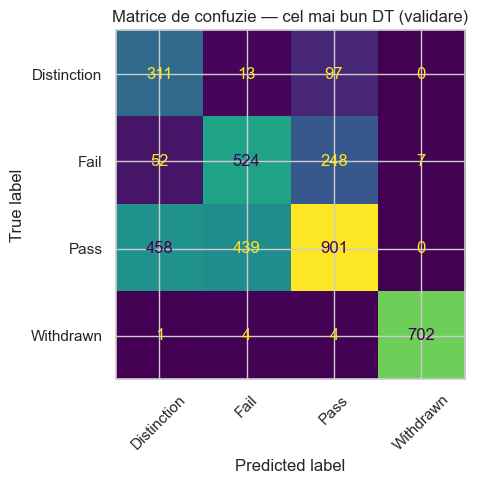

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_va,
    best_pred_va,
    display_labels=class_names,
    xticks_rotation=45,
    ax=ax,
    colorbar=False,
)
ax.set_title("Matrice de confuzie — cel mai bun DT (validare)")
plt.tight_layout()
plt.show()


### 3.3.2 Regresie — liniară + regularizare

Baseline: `LinearRegression`. Experimente: **Ridge** / **Lasso** cu diverși coeficienți `alpha`. Comparăm MAE / RMSE / R² pe train și validare.


In [37]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def reg_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }


reg_rows = []
models_reg = [
    ("LinearRegression", LinearRegression()),
    ("Ridge_a0.1", Ridge(alpha=0.1, random_state=RANDOM_STATE)),
    ("Ridge_a1", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    ("Ridge_a10", Ridge(alpha=10.0, random_state=RANDOM_STATE)),
    ("Lasso_a0.01", Lasso(alpha=0.01, random_state=RANDOM_STATE, max_iter=5000)),
    ("Lasso_a0.1", Lasso(alpha=0.1, random_state=RANDOM_STATE, max_iter=5000)),
]

for name, model in models_reg:
    model.fit(X_train_prep, y_train_reg)
    pred_tr = model.predict(X_train_prep)
    pred_va = model.predict(X_val_prep)
    m_tr = reg_metrics(y_train_reg, pred_tr)
    m_va = reg_metrics(y_val_reg, pred_va)
    reg_rows.append(
        {
            "model": name,
            "MAE_train": m_tr["MAE"],
            "MAE_val": m_va["MAE"],
            "RMSE_train": m_tr["RMSE"],
            "RMSE_val": m_va["RMSE"],
            "R2_train": m_tr["R2"],
            "R2_val": m_va["R2"],
        }
    )

tab_reg = pd.DataFrame(reg_rows)
display(tab_reg.round(4))


,model,MAE_train,MAE_val,RMSE_train,RMSE_val,R2_train,R2_val
0,LinearRegression,5.0104,5.0696,7.0364,7.0694,0.8252,0.8251
1,Ridge_a0.1,5.0122,5.0698,7.0374,7.0704,0.8252,0.8250
2,Ridge_a1,5.0122,5.0698,7.0374,7.0705,0.8252,0.8250
3,Ridge_a10,5.0125,5.0700,7.0375,7.0714,0.8252,0.8250
4,Lasso_a0.01,5.0110,5.0573,7.0423,7.0666,0.8249,0.8252
5,Lasso_a0.1,5.0458,5.0689,7.1133,7.1200,0.8214,0.8226


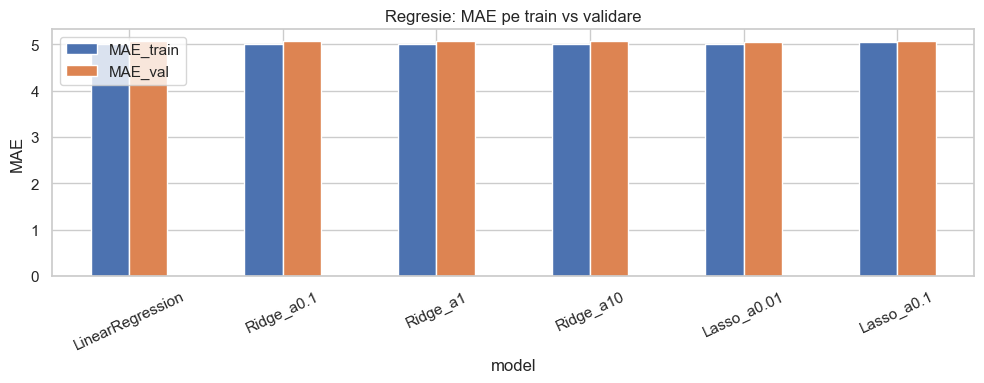

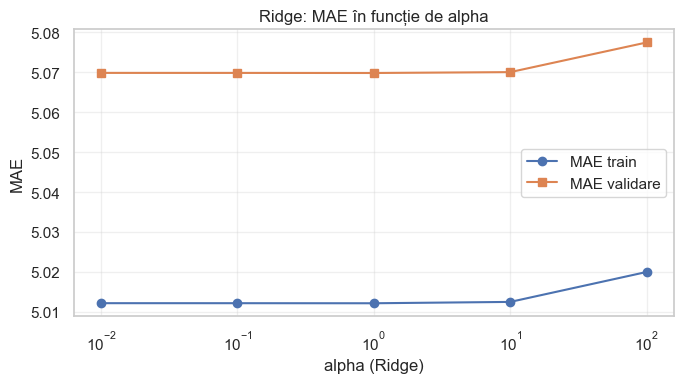

In [38]:
# Grafic comparativ: MAE train vs validare (evităm >10 curbe — un singur grafic cu câteva modele)
plot_df = tab_reg.set_index("model")[["MAE_train", "MAE_val"]]
ax = plot_df.plot(kind="bar", figsize=(10, 4), rot=25)
ax.set_ylabel("MAE")
ax.set_title("Regresie: MAE pe train vs validare")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

# Evoluție Ridge: alpha vs MAE (train și validare)
ridge_alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
mae_tr_r, mae_va_r = [], []
for a in ridge_alphas:
    r = Ridge(alpha=a, random_state=RANDOM_STATE)
    r.fit(X_train_prep, y_train_reg)
    mae_tr_r.append(mean_absolute_error(y_train_reg, r.predict(X_train_prep)))
    mae_va_r.append(mean_absolute_error(y_val_reg, r.predict(X_val_prep)))

plt.figure(figsize=(7, 4))
plt.plot(ridge_alphas, mae_tr_r, marker="o", label="MAE train")
plt.plot(ridge_alphas, mae_va_r, marker="s", label="MAE validare")
plt.xscale("log")
plt.xlabel("alpha (Ridge)")
plt.ylabel("MAE")
plt.title("Ridge: MAE în funcție de alpha")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 3.3.4 Rezumat (pentru PDF și platformă)

- Documentezi în raport: encodarea țintei clasificare (`LabelEncoder`), hiperparametrul variat la DT (`max_depth`), tipul regularizării și `alpha` la regresie.
- Adaugă tabele comparative finale (bold la max metrică cum cere enunțul) și comentarii despre overfit (gap train–validare).
- Predarea pe platformă (CSV de predicții) se face într-un pas separat când ai formatul oficial — de obicei antrenezi pe tot train-ul și generezi predicții pentru `CB_OUALD_test.csv` cu același pipeline.


### Legenda pentru tabele in raportul PDF

Cand pui in PDF tabele cu mai multe configuratii (modele, depth, alpha):
- **Bold** = cea mai buna valoare dupa metrica aleasa (ex. acuratete max pe validare sau MSE minim).
- **Subliniere** = a doua cea mai buna.
Scrie in text o propozitie care explica asta — altfel cititorul nu stie semnificatia formatarii.


### 3.3.3 (Opțional) Boosting — aliniat la Kaggle (acuratețe / MSE)

Pentru **leaderboard** (acuratețe la clasificare, **MSE** la regresie) antrenăm `HistGradientBoosting` pe aceleași matrice `X_train_prep` / `X_val_prep` și salvăm hiperparametrii câștigători pe validare. Celula de **generare predicții** le refolosește pe tot `train` pentru export. Arborele + regresia liniară din 3.3.1–3.3.2 rămân cerința minimă din enunț.


In [39]:
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, mean_squared_error

# Clasificare: maximizăm acuratețea pe validare (Kaggle = acuratețe, nu F1)
_sw = compute_sample_weight("balanced", y_tr)
best_acc_hgb = -1.0
HGB_CLF_BEST_PARAMS = None
for _md in (6, 10, 14, 18):
    for _lr in (0.05, 0.1):
        h = HistGradientBoostingClassifier(
            max_depth=_md,
            learning_rate=_lr,
            max_iter=450,
            min_samples_leaf=10,
            random_state=RANDOM_STATE,
        )
        h.fit(X_train_prep, y_tr, sample_weight=_sw)
        _acc = accuracy_score(y_va, h.predict(X_val_prep))
        if _acc > best_acc_hgb:
            best_acc_hgb = _acc
            HGB_CLF_BEST_PARAMS = {
                "max_depth": _md,
                "learning_rate": _lr,
                "max_iter": 450,
                "min_samples_leaf": 10,
            }
print("HGB clasificare — best acc_val =", round(best_acc_hgb, 4), "| params:", HGB_CLF_BEST_PARAMS)

# Regresie: minimizăm MSE pe validare (Kaggle = MSE)
best_mse_hgb = float("inf")
HGB_REG_BEST_PARAMS = None
for _md in (6, 10, 14):
    for _lr in (0.05, 0.1):
        r = HistGradientBoostingRegressor(
            max_depth=_md,
            learning_rate=_lr,
            max_iter=500,
            min_samples_leaf=10,
            l2_regularization=0.05,
            random_state=RANDOM_STATE,
        )
        r.fit(X_train_prep, y_train_reg)
        _mse = mean_squared_error(y_val_reg, r.predict(X_val_prep))
        if _mse < best_mse_hgb:
            best_mse_hgb = _mse
            HGB_REG_BEST_PARAMS = {
                "max_depth": _md,
                "learning_rate": _lr,
                "max_iter": 500,
                "min_samples_leaf": 10,
                "l2_regularization": 0.05,
            }
print("HGB regresie — best MSE_val =", round(best_mse_hgb, 4), "| params:", HGB_REG_BEST_PARAMS)


HGB clasificare — best acc_val = 0.7027 | params: {'max_depth': 14, 'learning_rate': 0.1, 'max_iter': 450, 'min_samples_leaf': 10}
HGB regresie — best MSE_val = 47.7078 | params: {'max_depth': 6, 'learning_rate': 0.05, 'max_iter': 500, 'min_samples_leaf': 10, 'l2_regularization': 0.05}


### 3.3.5 (Opțional) CatBoost — bonus Kaggle (tabular, fără one-hot)

Antrenăm **CatBoost** pe `X_tr` / `X_va` din 3.2 (același IQR), cu `cat_features=cat_feat`. Evităm matricea one-hot de la `ColumnTransformer` — de obicei crește mult acuratețea / scade MSE pe date de acest tip. Dacă lipsește pachetul: `pip install catboost` sau reîncarcă dependențele (`requirements.txt` conține `catboost`). Predicțiile finale preferă CatBoost față de HGB când antrenarea reușește.

În **aceeași celulă de cod** urmează **3.3.6 (opțional)**: **XGBoost** cu categorii native și blend cu CatBoost; ponderile se aleg **doar pe validarea** din antrenare (fără etichete de test).


In [40]:
# CatBoost pe date brute (DataFrame), fără one-hot
try:
    from catboost import CatBoostClassifier, CatBoostRegressor
except ImportError:
    print("Instalează: pip install catboost  (sau %pip install -r requirements.txt)")
    CB_CLF_KW = None
    CB_REG_KW = None
    XGB_BLEND_W_CLF = 1.0
    XGB_BLEND_W_REG = 1.0
    XGB_CLF_KW = None
    XGB_REG_KW = None

else:
    from copy import deepcopy
    from sklearn.metrics import accuracy_score, mean_squared_error

    def _as_cb_clf_y(a):
        return np.array([str(x) for x in np.ravel(np.asarray(a, dtype=object))], dtype=object)

    # Copii speciale pentru CatBoost
    X_tr_cb = X_tr.copy()
    X_va_cb = X_va.copy()

    # cat_feat poate conține fie index-uri, fie nume de coloane
    cat_cols = [
        X_tr_cb.columns[i] if isinstance(i, (int, np.integer)) else i
        for i in cat_feat
    ]

    # CatBoost nu acceptă NaN real în coloane categoriale.
    # Le convertim explicit la string.
    for c in cat_cols:
        X_tr_cb[c] = (
            X_tr_cb[c]
            .astype("object")
            .where(X_tr_cb[c].notna(), "__MISSING__")
            .astype(str)
        )

        X_va_cb[c] = (
            X_va_cb[c]
            .astype("object")
            .where(X_va_cb[c].notna(), "__MISSING__")
            .astype(str)
        )

    _y_tr_cb = _as_cb_clf_y(y_train_clf)
    _y_va_cb = _as_cb_clf_y(y_val_clf)

    _y_reg_tr = np.ascontiguousarray(np.ravel(y_train_reg), dtype=np.float64)
    _y_reg_va = np.ascontiguousarray(np.ravel(y_val_reg), dtype=np.float64)

    # -------------------------
    # Clasificare — grid mic: alegem acc max pe validare
    # -------------------------
    _clf_variants = [
        {
            "name": "d8_lr0.05",
            "depth": 8,
            "learning_rate": 0.05,
            "l2_leaf_reg": 3.0,
        },
        {
            "name": "d10_lr0.04",
            "depth": 10,
            "learning_rate": 0.04,
            "l2_leaf_reg": 2.5,
        },
        {
            "name": "d10_lr0.03",
            "depth": 10,
            "learning_rate": 0.03,
            "l2_leaf_reg": 2.0,
        },
        {
            "name": "d9_lr0.035",
            "depth": 9,
            "learning_rate": 0.035,
            "l2_leaf_reg": 2.0,
            "border_count": 128,
        },
        {
            "name": "d10_bag",
            "depth": 10,
            "learning_rate": 0.04,
            "l2_leaf_reg": 2.0,
            "bootstrap_type": "Bernoulli",
            "subsample": 0.88,
        },
        {
            "name": "d10_lr0.025",
            "depth": 10,
            "learning_rate": 0.025,
            "l2_leaf_reg": 1.8,
        },
        {
            "name": "d9_lr0.045",
            "depth": 9,
            "learning_rate": 0.045,
            "l2_leaf_reg": 2.2,
        },
        {
            "name": "d10_lr0.035_l3",
            "depth": 10,
            "learning_rate": 0.035,
            "l2_leaf_reg": 3.5,
        },
        {
            "name": "d7_slow",
            "depth": 7,
            "learning_rate": 0.028,
            "l2_leaf_reg": 4.0,
        },
        {
            "name": "d11_mild",
            "depth": 11,
            "learning_rate": 0.032,
            "l2_leaf_reg": 2.8,
            "min_data_in_leaf": 6,
        },
    ]

    _best_acc = -1.0
    _best_cbc = None
    _best_clf_label = None

    for v in _clf_variants:
        label = v["name"]
        _kw = {k: w for k, w in v.items() if k != "name"}
        _m = CatBoostClassifier(
            loss_function="MultiClass",
            eval_metric="Accuracy",
            random_seed=RANDOM_STATE,
            iterations=7000,
            early_stopping_rounds=320,
            use_best_model=True,
            auto_class_weights="Balanced",
            allow_writing_files=False,
            verbose=False,
            **_kw,
        )
        _m.fit(
            X_tr_cb,
            _y_tr_cb,
            eval_set=(X_va_cb, _y_va_cb),
            cat_features=cat_cols,
        )
        _acc = float(accuracy_score(_y_va_cb, _m.predict(X_va_cb)))
        if _acc > _best_acc:
            _best_acc = _acc
            _best_cbc = _m
            _best_clf_label = label
            _best_clf_base = deepcopy(_kw)

    _bi = _best_cbc.get_best_iteration()
    _it_c = int(_bi) + 1 if _bi is not None and int(_bi) >= 0 else 400

    print(
        "CatBoost clasificare — câștigător validare:",
        _best_clf_label,
        "| acc validare:",
        round(_best_acc, 4),
        "| iter (best):",
        _it_c,
    )

    CB_CLF_KW = {
        "loss_function": "MultiClass",
        "auto_class_weights": "Balanced",
        **(_best_clf_base),
        "iterations": _it_c,
    }

    # -------------------------
    # Regresie — grid mic (MSE minim pe validare, aliniat la metrica Kaggle)
    # -------------------------
    _reg_variants = [
        {
            "name": "d10",
            "depth": 10,
            "learning_rate": 0.05,
            "l2_leaf_reg": 2.0,
        },
        {
            "name": "d12_lr0.04",
            "depth": 12,
            "learning_rate": 0.04,
            "l2_leaf_reg": 1.5,
            "min_data_in_leaf": 3,
        },
        {
            "name": "d10_lr0.03",
            "depth": 10,
            "learning_rate": 0.03,
            "l2_leaf_reg": 1.0,
        },
        {
            "name": "d11_rs",
            "depth": 11,
            "learning_rate": 0.035,
            "l2_leaf_reg": 1.2,
            "random_strength": 0.25,
        },
        {
            "name": "d10_bag",
            "depth": 10,
            "learning_rate": 0.04,
            "l2_leaf_reg": 1.0,
            "bootstrap_type": "Bernoulli",
            "subsample": 0.9,
        },
        {
            "name": "d9_lr0.04",
            "depth": 9,
            "learning_rate": 0.04,
            "l2_leaf_reg": 1.3,
        },
        {
            "name": "d11_lr0.03",
            "depth": 11,
            "learning_rate": 0.03,
            "l2_leaf_reg": 1.0,
            "min_data_in_leaf": 4,
        },
        {
            "name": "d10_lr0.045",
            "depth": 10,
            "learning_rate": 0.045,
            "l2_leaf_reg": 1.8,
            "min_data_in_leaf": 5,
        },
        {
            "name": "d9_cons",
            "depth": 9,
            "learning_rate": 0.038,
            "l2_leaf_reg": 2.2,
            "min_data_in_leaf": 6,
        },
    ]

    _best_mse = float("inf")
    _best_cbr = None
    _best_reg_label = None

    for v in _reg_variants:
        label = v["name"]
        _kw = {k: w for k, w in v.items() if k != "name"}
        _m = CatBoostRegressor(
            loss_function="RMSE",
            eval_metric="RMSE",
            random_seed=RANDOM_STATE,
            iterations=9000,
            early_stopping_rounds=360,
            use_best_model=True,
            allow_writing_files=False,
            verbose=False,
            **_kw,
        )
        _m.fit(
            X_tr_cb,
            _y_reg_tr,
            eval_set=(X_va_cb, _y_reg_va),
            cat_features=cat_cols,
        )
        _pv = _m.predict(X_va_cb)
        _mse = float(mean_squared_error(_y_reg_va, _pv))
        if _mse < _best_mse:
            _best_mse = _mse
            _best_cbr = _m
            _best_reg_label = label
            _best_reg_base = deepcopy(_kw)

    _bir = _best_cbr.get_best_iteration()
    _it_r = int(_bir) + 1 if _bir is not None and int(_bir) >= 0 else 500

    print(
        "CatBoost regresie — câștigător validare:",
        _best_reg_label,
        "| MSE validare:",
        round(_best_mse, 4),
        "| iter (best):",
        _it_r,
    )

    CB_REG_KW = {
        "loss_function": "RMSE",
        **(_best_reg_base),
        "iterations": _it_r,
    }
    # --- 3.3.6 XGBoost (opțional): blend cu CatBoost; ponderea se alege DOAR pe validare ---
    XGB_BLEND_W_CLF = 1.0
    XGB_BLEND_W_REG = 1.0
    XGB_CLF_KW = None
    XGB_REG_KW = None
    try:
        import xgboost as xgb
        from sklearn.preprocessing import LabelEncoder as _LE_xgb

        def _align_cat_proba_to_le(cbc, X_cb, le):
            P = cbc.predict_proba(X_cb)
            C = np.asarray(cbc.classes_, dtype=object)
            n, K = P.shape[0], len(le.classes_)
            out = np.zeros((n, K))
            for j in range(K):
                lab = le.classes_[j]
                s = str(lab)
                match = np.nonzero(C.astype(str) == s)[0]
                if len(match):
                    out[:, j] = P[:, int(match[0])]
            return out

        def _df_xgb_cat(X):
            o = X.copy()
            for c in cat_cols:
                o[c] = o[c].astype("category")
            return o

        _le_x = _LE_xgb()
        _le_x.fit(df_train[TARGET_CLF].astype(str))
        _y_tr_x = _le_x.transform(pd.Series(_y_tr_cb, dtype=object).astype(str))
        _y_va_x = _le_x.transform(pd.Series(_y_va_cb, dtype=object).astype(str))
        _Kx = int(len(_le_x.classes_))

        X_tr_x = _df_xgb_cat(X_tr_cb)
        X_va_x = _df_xgb_cat(X_va_cb)

        _xgb_clf_configs = [
            {
                "name": "xd8",
                "max_depth": 8,
                "learning_rate": 0.05,
                "subsample": 0.88,
                "colsample_bytree": 0.85,
                "min_child_weight": 2.0,
                "reg_lambda": 1.5,
            },
            {
                "name": "xd9",
                "max_depth": 9,
                "learning_rate": 0.042,
                "subsample": 0.9,
                "colsample_bytree": 0.8,
                "min_child_weight": 1.5,
                "reg_lambda": 2.0,
            },
            {
                "name": "xd7",
                "max_depth": 7,
                "learning_rate": 0.055,
                "subsample": 0.86,
                "colsample_bytree": 0.88,
                "min_child_weight": 2.0,
                "reg_lambda": 1.2,
            },
            {
                "name": "xd10",
                "max_depth": 10,
                "learning_rate": 0.035,
                "subsample": 0.9,
                "colsample_bytree": 0.82,
                "min_child_weight": 2.5,
                "reg_lambda": 1.8,
            },
            {
                "name": "xd11_m",
                "max_depth": 11,
                "learning_rate": 0.028,
                "subsample": 0.88,
                "colsample_bytree": 0.78,
                "min_child_weight": 3.0,
                "reg_lambda": 2.2,
            },
        ]
        _best_xclf = None
        _best_xc_name = ""
        _best_xc_kw_save = {}
        _best_xc_acc_solo = -1.0
        for _xcc in _xgb_clf_configs:
            _nm = _xcc["name"]
            _kwc = {k: v for k, v in _xcc.items() if k != "name"}
            _mx = xgb.XGBClassifier(
                objective="multi:softprob",
                num_class=_Kx,
                n_estimators=5200,
                tree_method="hist",
                enable_categorical=True,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                early_stopping_rounds=200,
                eval_metric="mlogloss",
                **_kwc,
            )
            _mx.fit(
                X_tr_x,
                _y_tr_x,
                eval_set=[(X_va_x, _y_va_x)],
                verbose=False,
            )
            _acc_s = float(accuracy_score(_y_va_x, _mx.predict(X_va_x)))
            if _acc_s > _best_xc_acc_solo:
                _best_xc_acc_solo = _acc_s
                _best_xclf = _mx
                _best_xc_name = _nm
                _best_xc_kw_save = dict(_kwc)

        _bix = getattr(_best_xclf, "best_iteration", None)
        _it_xc = int(_bix) + 1 if _bix is not None and int(_bix) >= 0 else 400

        _Pc_va = _align_cat_proba_to_le(_best_cbc, X_va_cb, _le_x)
        _Px_va = _best_xclf.predict_proba(X_va_x)
        _best_w_c = 1.0
        _best_acc_b = -1.0
        if _Px_va.shape[1] == _Kx:
            _w_grid_c = list(np.round(np.linspace(1.0, 0.18, 45), 4))
            for _w in _w_grid_c:
                _Pbl = _w * _Pc_va + (1.0 - _w) * _Px_va
                _pred_va = _le_x.inverse_transform(np.argmax(_Pbl, axis=1))
                _acc_b = float(accuracy_score(_y_va_cb, _pred_va.astype(str)))
                if _acc_b > _best_acc_b:
                    _best_acc_b = _acc_b
                    _best_w_c = _w

        XGB_CLF_KW = {
            "objective": "multi:softprob",
            "num_class": _Kx,
            "n_estimators": _it_xc,
            "tree_method": "hist",
            "enable_categorical": True,
            **_best_xc_kw_save,
        }

        _xgb_reg_configs = [
            {
                "name": "xr10",
                "max_depth": 10,
                "learning_rate": 0.05,
                "subsample": 0.9,
                "colsample_bytree": 0.85,
                "min_child_weight": 2.0,
                "reg_lambda": 1.2,
            },
            {
                "name": "xr9",
                "max_depth": 9,
                "learning_rate": 0.04,
                "subsample": 0.88,
                "colsample_bytree": 0.82,
                "min_child_weight": 2.5,
                "reg_lambda": 1.5,
            },
            {
                "name": "xr11",
                "max_depth": 11,
                "learning_rate": 0.032,
                "subsample": 0.9,
                "colsample_bytree": 0.88,
                "min_child_weight": 1.5,
                "reg_lambda": 1.0,
            },
            {
                "name": "xr8",
                "max_depth": 8,
                "learning_rate": 0.055,
                "subsample": 0.87,
                "colsample_bytree": 0.9,
                "min_child_weight": 2.5,
                "reg_lambda": 1.4,
            },
            {
                "name": "xr7_s",
                "max_depth": 7,
                "learning_rate": 0.045,
                "subsample": 0.92,
                "colsample_bytree": 0.85,
                "min_child_weight": 3.0,
                "reg_lambda": 1.8,
            },
        ]
        _best_xreg = None
        _best_xr_name = ""
        _best_xr_kw_save = {}
        _best_mse_x_solo = float("inf")
        for _xrc in _xgb_reg_configs:
            _nmr = _xrc["name"]
            _kwr = {k: v for k, v in _xrc.items() if k != "name"}
            _mxr = xgb.XGBRegressor(
                n_estimators=7000,
                tree_method="hist",
                enable_categorical=True,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                early_stopping_rounds=220,
                eval_metric="rmse",
                **_kwr,
            )
            _mxr.fit(
                X_tr_x,
                _y_reg_tr,
                eval_set=[(X_va_x, _y_reg_va)],
                verbose=False,
            )
            _mse_x = float(mean_squared_error(_y_reg_va, _mxr.predict(X_va_x)))
            if _mse_x < _best_mse_x_solo:
                _best_mse_x_solo = _mse_x
                _best_xreg = _mxr
                _best_xr_name = _nmr
                _best_xr_kw_save = dict(_kwr)

        _birx = getattr(_best_xreg, "best_iteration", None)
        _it_xr = int(_birx) + 1 if _birx is not None and int(_birx) >= 0 else 500

        _pv_c = _best_cbr.predict(X_va_cb)
        _pv_x = _best_xreg.predict(X_va_x)
        _best_w_r = 1.0
        _best_mse_b = float("inf")
        _w_grid_r = list(np.round(np.linspace(1.0, 0.18, 45), 4))
        for _w in _w_grid_r:
            _pr = _w * _pv_c + (1.0 - _w) * _pv_x
            _mse_b = float(mean_squared_error(_y_reg_va, _pr))
            if _mse_b < _best_mse_b:
                _best_mse_b = _mse_b
                _best_w_r = _w

        XGB_REG_KW = {
            "n_estimators": _it_xr,
            "tree_method": "hist",
            "enable_categorical": True,
            **_best_xr_kw_save,
        }

        XGB_BLEND_W_CLF = float(_best_w_c)
        XGB_BLEND_W_REG = float(_best_w_r)
        print(
            "XGBoost — blend validare: cfg_clf=",
            _best_xc_name,
            "cfg_reg=",
            _best_xr_name,
            "| w_cat_clf=",
            round(XGB_BLEND_W_CLF, 3),
            "| acc blend val ~",
            round(_best_acc_b, 4),
            "| w_cat_reg=",
            round(XGB_BLEND_W_REG, 3),
            "| MSE blend val ~",
            round(_best_mse_b, 4),
        )
    except Exception as _e_xgb:
        print("XGBoost opțional oprit:", type(_e_xgb).__name__, str(_e_xgb)[:200])



CatBoost clasificare — câștigător validare: d9_lr0.045 | acc validare: 0.7078 | iter (best): 438
CatBoost regresie — câștigător validare: d9_cons | MSE validare: 46.7801 | iter (best): 964
XGBoost — blend validare: cfg_clf= xd10 cfg_reg= xr7_s | w_cat_clf= 0.255 | acc blend val ~ 0.7602 | w_cat_reg= 0.609 | MSE blend val ~ 46.3773


---
### Generare predicții pentru `CB_OUALD_test.csv` și (opțional) Kaggle

- **Fișierele primite** (`CB_OUALD_train.csv`, `CB_OUALD_test.csv`) **nu se modifică** — doar se citesc.
- Rezultatele pentru **tema (Moodle / arhivă)** se scriu în `CB_OUALD_predictii_tema1.csv`, cu coloanele `final_result`, `final_coursework_score` (o linie = o linie din setul de test al temei, aceeași ordine).
- **Kaggle (bonus, două competiții):** descarcă `CB_private_test.csv` din fila **Data** a fiecărei competiții (`TEMA1_IA_CB_CLASIFICARE_2026` și `TEMA1_IA_CB_REGRESIE_2026` — e același set de rânduri) și pune-l în acest folder ca `CB_private_test.csv`. Dacă fișierul există, ultima celulă de cod îl folosește la intrare (inclusiv coloana `id`); generează:
  - `kaggle_TEMA1_CB_clasificare_2026.csv` — coloane `id`, `prediction` (etichete clasificare, ca șiruri)
  - `kaggle_TEMA1_CB_regresie_2026.csv` — coloane `id`, `prediction` (numere, scor)
  Încarci fiecare CSV în competiția **corespunzătoare** (filă **Submissions**), nu le amesteca. Dacă `CB_private_test.csv` lipsește, se folosește doar `CB_OUALD_test.csv` și se exportă oricum fișierele Kaggle cu `id` = 1, 2, …, N (asigură-te că pui fișierul de pe Kaggle înainte de submit, ca `id` să coincidă).
- Pipeline-ul se **antrenează pe tot `df_train`**, apoi se aplică pe setul de test ales; experimentele din 3.3 rămân pe split-ul train/validare.


## Generare predicții (Moodle + Kaggle bonus)

- `CB_OUALD_predictii_tema1.csv` — Moodle
- `kaggle_TEMA1_CB_clasificare_2026.csv` — Kaggle clasificare (`id`, `prediction`)
- `kaggle_TEMA1_CB_regresie_2026.csv` — Kaggle regresie (`id`, `prediction` float)

Pipeline: CatBoost multi-seed + stacking (scor regresie OOF). Rulează `kaggle_export.py`.


In [42]:
# Export final — ruleaza kaggle_export.py
from pathlib import Path
import kaggle_export

kaggle_export.main(Path('.'))
print('Moodle:', Path('CB_OUALD_predictii_tema1.csv').resolve())
print('Kaggle CLF:', Path('kaggle_TEMA1_CB_clasificare_2026.csv').resolve())
print('Kaggle REG:', Path('kaggle_TEMA1_CB_regresie_2026.csv').resolve())


Data loaded (18802, 41)
OOF reg...
Reg Moodle...
  reg seed 42 ok (4700)
  reg seed 137 ok (4700)
Reg Kaggle...
  reg seed 42 ok (4700)
  reg seed 137 ok (4700)
MSE val 46.9279
acc val 0.7076
Clf export...
Export OK .
Moodle: C:\Users\Andrei\Desktop\SEM_2\IA\LAB-uri\TEME\TEMA1\Tema1-CB\CB_OUALD_predictii_tema1.csv
Kaggle CLF: C:\Users\Andrei\Desktop\SEM_2\IA\LAB-uri\TEME\TEMA1\Tema1-CB\kaggle_TEMA1_CB_clasificare_2026.csv
Kaggle REG: C:\Users\Andrei\Desktop\SEM_2\IA\LAB-uri\TEME\TEMA1\Tema1-CB\kaggle_TEMA1_CB_regresie_2026.csv
